# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Preprocessing

- Get the data from the file [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).


- Create a dataframe `df` with the columns: `date`, `am`, `pm`, `target`, where `date` is the date of the day, `am` is the number of the commits during the day before midday (integer), `pm` is the number of commits during the day after midday (integer), `target` is weekend/working_day.

In [2]:
df_raw = pd.read_csv('data/checker_timestamp.csv')

df_raw.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['date'] = df_raw['timestamp'].dt.date
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['is_am'] = df_raw['hour'] < 12

print(df_raw.shape)
print(df_raw['date'].nunique())
df_raw.head()

(3207, 4)
35


,timestamp,date,hour,is_am
0,2020-04-17 05:19:02.744528,2020-04-17,5,True
1,2020-04-17 05:22:35.249331,2020-04-17,5,True
2,2020-04-17 05:22:45.549397,2020-04-17,5,True
3,2020-04-17 05:34:14.691200,2020-04-17,5,True
4,2020-04-17 05:34:24.422370,2020-04-17,5,True


In [4]:
df = df_raw.groupby('date').apply(lambda x: pd.Series({'am': (x['is_am']).sum(),
                                                        'pm': (~x['is_am']).sum()})).reset_index()

df.head()

,date,am,pm
0,2020-04-17,21,2
1,2020-04-18,1,68
2,2020-04-19,18,15
3,2020-04-20,2,23
4,2020-04-21,0,25


In [5]:
df['date'] = pd.to_datetime(df['date'])
df['target'] = df['date'].dt.dayofweek.apply(lambda x: 'weekend' if x >= 5 else 'working_day')

df.head()

,date,am,pm,target
0,2020-04-17,21,2,working_day
1,2020-04-18,1,68,weekend
2,2020-04-19,18,15,weekend
3,2020-04-20,2,23,working_day
4,2020-04-21,0,25,working_day


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    35 non-null     datetime64[s]
 1   am      35 non-null     int64        
 2   pm      35 non-null     int64        
 3   target  35 non-null     str          
dtypes: datetime64[s](1), int64(2), str(1)
memory usage: 1.2 KB


## 2. Exploratory analysis

- Create a plot where `x` is am, `y` is pm, each dot is a day, working days and weekends must have different colors.


- By looking at the graph do you think it will be easy to classify the days having those two features? Put your answer in the markdown cell in the end of that sectioin: "yes, it is easy" or "no, it is not easy".

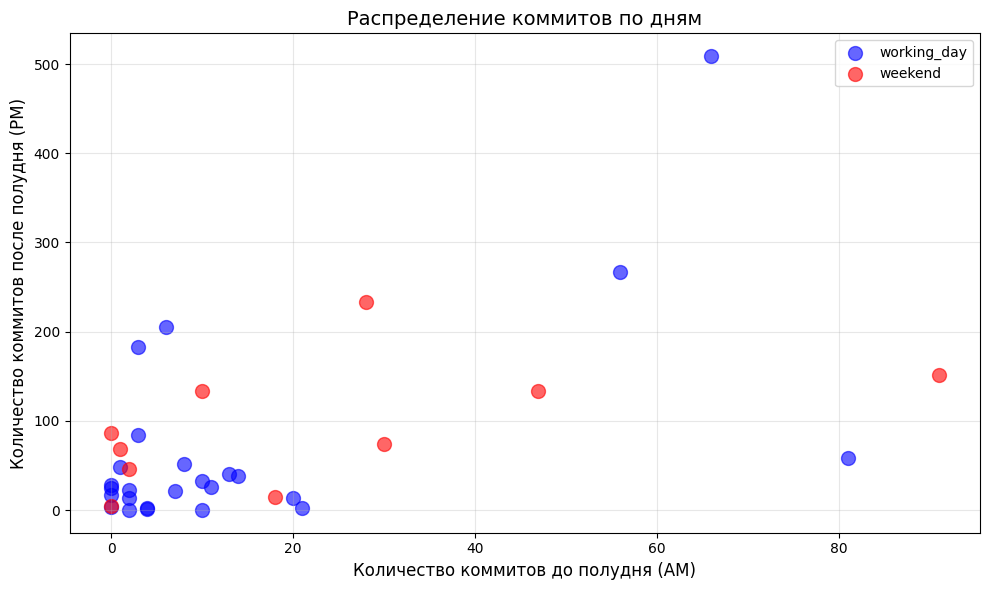

In [7]:
working_days = df[df['target'] == 'working_day']
weekends = df[df['target'] == 'weekend']

plt.figure(figsize=(10, 6))

plt.scatter(working_days['am'], working_days['pm'], label='working_day', alpha=0.6, s=100, color='blue')
plt.scatter(weekends['am'], weekends['pm'], label='weekend', alpha=0.6, s=100, color='red')

plt.xlabel('Количество коммитов до полудня (AM)', fontsize=12)
plt.ylabel('Количество коммитов после полудня (PM)', fontsize=12)
plt.title('Распределение коммитов по дням', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос: Судя по графику, легко ли будет классифицировать дни при помощи количества коммитов до и после полудня в качестве незасимых переменных?**

**Ответ: нет, не легко.**

## 3. Logistic regression

- Train logistic regression on your data using `am` and `pm`, parameters are: `random state=21`, `fit_intercept=False`.


- Make predictions for every day of your dataset and add them to your dataframe with the column name `predict`.


- Save the dataframe into a file in the subfolder of the day `data` with the name `am_pm.csv`.


- Draw another plot like you did before, but the color should be taken from the `predict`.


- By looking at the graph do you think if it made good predictions? Put your answer in the markdown cell in the end of that section: "yes, it is good"; "no, it is not good".

In [8]:
X = df[['am', 'pm']].values
y = df['target'].values

In [9]:
model = LogisticRegression(random_state=21, fit_intercept=False).fit(X, y)

In [10]:
y_pred = model.predict(X)
df['predict'] = y_pred

df.head()

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day


In [11]:
df[['date', 'am', 'pm', 'target', 'predict']].to_csv('data/am_pm.csv', index=False)

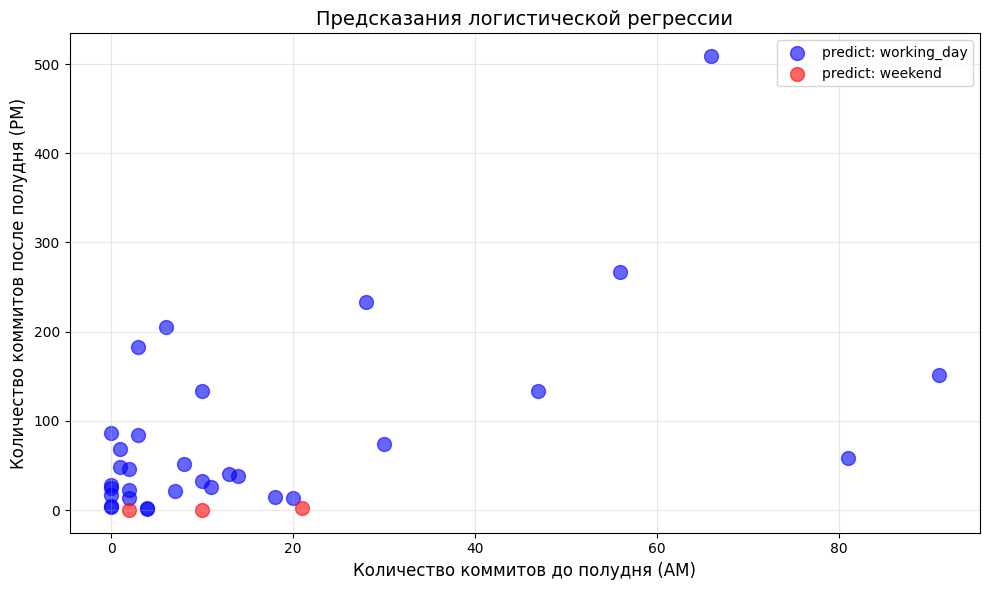

In [12]:
pred_working  = df[df['predict'] == 'working_day']
pred_weekends = df[df['predict'] == 'weekend']

plt.figure(figsize=(10, 6))
plt.scatter(pred_working['am'],  pred_working['pm'],  label='predict: working_day', alpha=0.6, s=100, color='blue')
plt.scatter(pred_weekends['am'], pred_weekends['pm'], label='predict: weekend',     alpha=0.6, s=100, color='red')

plt.xlabel('Количество коммитов до полудня (AM)', fontsize=12)
plt.ylabel('Количество коммитов после полудня (PM)', fontsize=12)
plt.title('Предсказания логистической регрессии', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Судя по графику, сделал ли классификатор хорошие предсказания?**

**Ответ: нет, предсказательная способность слабая** (почти все выходные дни классифицированы как будни, если сравнивать с графиком истинных значений)

## 4. Evaluation

- Calculate `accuracy` for your predictions.


- Calculate `accuracy` for the naive case when each of your prediction is the value of your most popular class of the day.


- Comparing the accuracies do you think that the classifier made good predictions? Put your answer in the markdown cell in the end of the secion: "yes, it is good"; "no, it is not good".

In [13]:
accuracy_model = accuracy_score(y, y_pred)
print(f"Accuracy логистической регрессии: {accuracy_model}")

Accuracy логистической регрессии: 0.6285714285714286


In [14]:
most_common_class = df['target'].value_counts().idxmax()
y_naive_baseline = np.full_like(y, most_common_class)
accuracy_naive_baseline = accuracy_score(y, y_naive_baseline)
print(f"Accuracy наивного \"классификатора\": {accuracy_naive_baseline}")
print(f'\nРазница между accuracy логистической регрессии и наивного "классификатора": {(accuracy_model - accuracy_naive_baseline)}')

Accuracy наивного "классификатора": 0.7142857142857143

Разница между accuracy логистической регрессии и наивного "классификатора": -0.08571428571428574


**Вопрос: Сравнивая показатели accuracy для логистической регрессии и наивного "классификатора", можно ли утверждать, что [логистический] классификатор справился с задачей хорошо?**

**Ответ: нет, наш классификатор справился плохо** (его точность даже ниже, чем у наивного).